y_train: -587.6308030899363 507.2599556073562 0.7376734809929834 194.66027796159594
y_test : -507.03966187825176 558.9540702593537 5.9528431894663445 200.903012150969

train OOB map
  L2: mean=1.000000 std=0.000000 min=1.000000 max=1.000000
  L1: mean=22.360685 std=0.000004 min=22.360682 max=22.360682

train full-as-OOS map
  L2: mean=1.000000 std=0.000000 min=1.000000 max=1.000000
  L1: mean=22.360685 std=0.000004 min=22.360682 max=22.360682

test full OOS map
  L2: mean=1.000000 std=0.000000 min=1.000000 max=1.000000
  L1: mean=22.360682 std=0.000000 min=22.360682 max=22.360682

No OOS calibration
  train OOB variance:          [0.0022105  0.00212729]
  train full-as-OOS variance:  [0.0022105  0.00212729]
  test raw variance:           [0.00190197 0.00119456]
  test final variance:         [0.00190197 0.00119456]


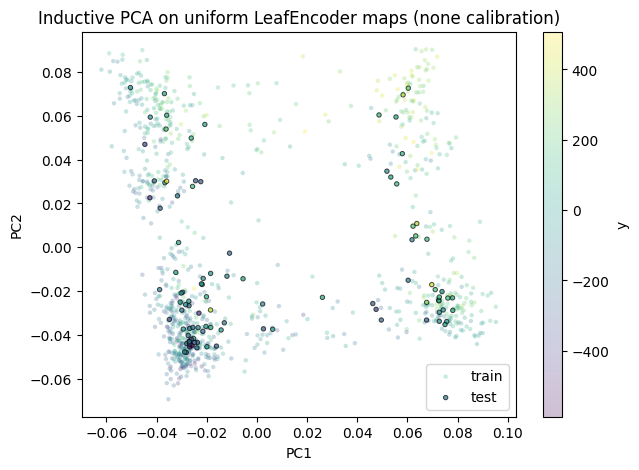

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

from forestkernel import LeafEncoder


seed = 42
calibration = "none"  # choose: "none", "global", "componentwise"
weight_scheme = "uniform"  # choose: "oob", "uniform", "leafsize"

# -------------------------------------------------------
# Data
# -------------------------------------------------------

X, y = make_regression(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    noise=10.0,
    random_state=seed,
)

bins = np.quantile(y, np.linspace(0, 1, 11))
y_bins = np.digitize(y, bins[1:-1])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    stratify=y_bins,
    random_state=seed,
)

print("y_train:", y_train.min(), y_train.max(), y_train.mean(), y_train.std())
print("y_test :", y_test.min(), y_test.max(), y_test.mean(), y_test.std())


# -------------------------------------------------------
# Fit LeafEncoder
# -------------------------------------------------------

forest = RandomForestRegressor(
    bootstrap=True,
    n_estimators=500,
    # min_samples_leaf=10,
    n_jobs=-1,
    random_state=seed,
)

enc = LeafEncoder(
    forest=forest,
    weight_scheme=weight_scheme,
)

enc.fit(X_train, y_train)

leaf_train_oob = enc.training_query_map()
leaf_train_full = enc.transform(X_train)
leaf_test = enc.transform(X_test)


# -------------------------------------------------------
# Norm diagnostics
# -------------------------------------------------------

def summarize_row_norms(name, A):
    l2 = np.sqrt(A.multiply(A).sum(axis=1)).A1
    l1 = np.asarray(np.abs(A).sum(axis=1)).ravel()

    print(f"\n{name}")
    print(
        f"  L2: mean={l2.mean():.6f} std={l2.std():.6f} "
        f"min={l2.min():.6f} max={l2.max():.6f}"
    )
    print(
        f"  L1: mean={l1.mean():.6f} std={l1.std():.6f} "
        f"min={l1.min():.6f} max={l1.max():.6f}"
    )

summarize_row_norms("train OOB map", leaf_train_oob)
summarize_row_norms("train full-as-OOS map", leaf_train_full)
summarize_row_norms("test full OOS map", leaf_test)


# -------------------------------------------------------
# PCA + optional training-only OOS calibration
# -------------------------------------------------------

pca_leaf = PCA(n_components=2, random_state=seed)

Z_train = pca_leaf.fit_transform(leaf_train_oob)
Z_train_full = pca_leaf.transform(leaf_train_full)
Z_test_raw = pca_leaf.transform(leaf_test)

eps = 1e-12

if calibration == "none":
    oos_scale = 1.0
    Z_test = Z_test_raw
    print("\nNo OOS calibration")

elif calibration == "global":
    num = np.sum(Z_train * Z_train_full)
    den = np.sum(Z_train_full ** 2)
    oos_scale = num / den if den > eps else 1.0
    Z_test = oos_scale * Z_test_raw

    print("\nGlobal OOS calibration")
    print(f"  learned OOS scale: {oos_scale:.6f}")

elif calibration == "componentwise":
    var_oob = Z_train.var(axis=0)
    var_full = Z_train_full.var(axis=0)

    oos_scale = np.sqrt(var_oob / np.maximum(var_full, eps))
    Z_test = Z_test_raw * oos_scale

    print("\nComponentwise OOS calibration")
    print("  learned OOS scale vector:", oos_scale)

else:
    raise ValueError("calibration must be one of {'none', 'global', 'componentwise'}")

print("  train OOB variance:         ", Z_train.var(axis=0))
print("  train full-as-OOS variance: ", Z_train_full.var(axis=0))
print("  test raw variance:          ", Z_test_raw.var(axis=0))
print("  test final variance:        ", Z_test.var(axis=0))


# -------------------------------------------------------
# Plot
# -------------------------------------------------------

Z = np.vstack([Z_train_full, Z_test])
y_all = np.concatenate([y_train, y_test])
split_all = np.array(["train"] * len(X_train) + ["test"] * len(X_test))

plt.figure(figsize=(7, 5))

train_mask = split_all == "train"
sc = plt.scatter(
    Z[train_mask, 0],
    Z[train_mask, 1],
    c=y_all[train_mask],
    marker="o",
    s=10,
    alpha=0.25,
    linewidths=0,
    label="train",
)

test_mask = split_all == "test"
plt.scatter(
    Z[test_mask, 0],
    Z[test_mask, 1],
    c=y_all[test_mask],
    marker="o",
    s=10,
    alpha=0.70,
    edgecolors="black",
    linewidths=0.7,
    label="test",
)

plt.title(f"Inductive PCA on {weight_scheme} LeafEncoder maps ({calibration} calibration)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.colorbar(sc, label="y")
plt.show()